Cell 1 — Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Pandas: 3.0.6
NumPy: 2.5.3
TensorFlow: 2.21.0
GPU: []


Cell 2 — Load your model dataset

In [5]:
model_path = r"C:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\data\processed\final\stock_macro_monthly_target.parquet"

df = pd.read_parquet(model_path)

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Unique stocks:", df["isin"].nunique())

Shape: (60846, 23)
Date range: 2010-01-01 00:00:00 → 2026-09-01 00:00:00
Unique stocks: 437


Cell 3 — Select RELIANCE

In [6]:
reliance = (
    df[df["symbol"] == "RELIANCE"]
    .sort_values("date")
    .reset_index(drop=True)
)

print("RELIANCE observations:", len(reliance))
print("Date range:", reliance["date"].min(), "→", reliance["date"].max())

display(reliance.head())

RELIANCE observations: 201
Date range: 2010-01-01 00:00:00 → 2026-09-01 00:00:00


,isin,symbol,monthly_open,monthly_high,monthly_low,monthly_close,monthly_adj_close,monthly_volume,trading_days,date,...,cpi_index,cpi_inflation_yoy_pct,oil_return_1m_pct,oil_return_12m_pct,gold_return_1m_pct,gold_return_12m_pct,inflation_change_1m,house_price_index,hpi_growth_12m_pct,target_return_1m
0,INE002A01018,RELIANCE,249.407104,262.847809,232.720535,239.143723,211.659332,642993345.0,19,2010-01-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.428039
1,INE002A01018,RELIANCE,237.155045,241.463837,219.245560,223.771500,198.053787,324665427.0,19,2010-02-01,...,NaN,NaN,8.578222,NaN,3.192272,NaN,NaN,NaN,NaN,9.734929
2,INE002A01018,RELIANCE,225.154434,253.955917,223.874359,245.555481,217.334183,419629083.0,21,2010-03-01,...,NaN,NaN,6.585901,NaN,-3.187257,NaN,NaN,NaN,NaN,-3.784027
3,INE002A01018,RELIANCE,246.412659,262.802094,231.326172,236.263580,209.110199,376994477.0,20,2010-04-01,...,NaN,NaN,5.731567,NaN,4.698833,NaN,NaN,NaN,NaN,1.909299
4,INE002A01018,RELIANCE,234.526337,249.932846,223.097183,239.006577,213.102737,475654929.0,21,2010-05-01,...,NaN,NaN,-15.347673,NaN,7.613534,NaN,NaN,NaN,NaN,4.232022


Cell 4 — Select LSTM features and target

In [7]:
features = [
    "stock_return_1m",
    "monthly_adj_close",
    "monthly_volume",
    "oil_price_usd_bbl",
    "gold_price_inr_10g"
]

target = "target_return_1m"

data = reliance[["date"] + features + [target]].copy()

print("Features:")
for feature in features:
    print(" -", feature)

print("\nTarget:", target)

print("\nMissing values:")
print(data[features + [target]].isna().sum())

Features:
 - stock_return_1m
 - monthly_adj_close
 - monthly_volume
 - oil_price_usd_bbl
 - gold_price_inr_10g

Target: target_return_1m

Missing values:
stock_return_1m       0
monthly_adj_close     0
monthly_volume        0
oil_price_usd_bbl     0
gold_price_inr_10g    0
target_return_1m      1
dtype: int64


Cell 5 — Remove unusable rows

In [8]:
data = data.dropna().reset_index(drop=True)

print("Shape after removing missing values:", data.shape)
print("Date range:", data["date"].min(), "→", data["date"].max())

display(data.head())
display(data.tail())

Shape after removing missing values: (200, 7)
Date range: 2010-01-01 00:00:00 → 2026-08-01 00:00:00


,date,stock_return_1m,monthly_adj_close,monthly_volume,oil_price_usd_bbl,gold_price_inr_10g,target_return_1m
0,2010-01-01,-4.066738,211.659332,642993345.0,71.459999,16050.981650,-6.428039
1,2010-02-01,-6.428039,198.053787,324665427.0,77.589996,16563.372599,9.734929
2,2010-03-01,9.734929,217.334183,419629083.0,82.699997,16035.455348,-3.784027
3,2010-04-01,-3.784027,209.110199,376994477.0,87.440002,16788.934644,1.909299
4,2010-05-01,1.909299,213.102737,475654929.0,74.019997,18067.165857,4.232022


,date,stock_return_1m,monthly_adj_close,monthly_volume,oil_price_usd_bbl,gold_price_inr_10g,target_return_1m
195,2026-04-01,6.466260,1424.215088,449168049.0,114.010002,141278.712265,-7.660058
196,2026-05-01,-7.660058,1315.119385,329539497.0,92.050003,140289.387658,-1.613493
197,2026-06-01,-1.613493,1293.900024,350576163.0,72.919998,123076.729941,1.074273
198,2026-07-01,1.074273,1307.800049,271122919.0,90.120003,126345.190545,-2.355104
199,2026-08-01,-2.355104,1277.000000,234416938.0,90.489998,137427.345530,-3.962410


Cell 5 — Train / validation / test split

In [9]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

test_size = 24

# Final 24 observations = test set
train_val = data.iloc[:-test_size].copy()
test = data.iloc[-test_size:].copy()

# Last 20% of train_val = validation
val_size = int(len(train_val) * 0.20)

train = train_val.iloc[:-val_size].copy()
validation = train_val.iloc[-val_size:].copy()

print("=" * 70)
print("DATA SPLIT")
print("=" * 70)

print("\nTraining:")
print("Observations:", len(train))
print("Period:", train["date"].min(), "→", train["date"].max())

print("\nValidation:")
print("Observations:", len(validation))
print("Period:", validation["date"].min(), "→", validation["date"].max())

print("\nTesting:")
print("Observations:", len(test))
print("Period:", test["date"].min(), "→", test["date"].max())

DATA SPLIT

Training:
Observations: 141
Period: 2010-01-01 00:00:00 → 2021-09-01 00:00:00

Validation:
Observations: 35
Period: 2021-10-01 00:00:00 → 2024-08-01 00:00:00

Testing:
Observations: 24
Period: 2024-09-01 00:00:00 → 2026-08-01 00:00:00


Cell 7 — Scale the features

In [10]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# SCALE INPUT FEATURES
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(train[features])

# Transform train, validation, and test
X_train_scaled = scaler.transform(train[features])
X_val_scaled = scaler.transform(validation[features])
X_test_scaled = scaler.transform(test[features])

print("Scaled shapes:")
print("X_train:", X_train_scaled.shape)
print("X_val:  ", X_val_scaled.shape)
print("X_test: ", X_test_scaled.shape)

Scaled shapes:
X_train: (141, 5)
X_val:   (35, 5)
X_test:  (24, 5)


In [11]:
print("Training means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train_scaled.std(axis=0))

Training means:
[-1.25982755e-17 -1.00786204e-16  0.00000000e+00 -5.03931018e-17
 -9.07075833e-16]

Training standard deviations:
[1. 1. 1. 1. 1.]


Cell 8 — Create LSTM sequences

In [13]:
# ============================================================
# CORRECT TIME-SERIES SEQUENCES
# ============================================================

LOOKBACK = 12


def create_sequences_with_context(
    X_context,
    X_data,
    y_data,
    lookback
):
    """
    X_context:
        Previous observations used only as historical context.

    X_data:
        Data for the period we actually want predictions for.

    y_data:
        Targets corresponding to X_data.
    """

    # Combine historical context + current period
    X_combined = np.concatenate(
        [X_context, X_data],
        axis=0
    )

    X_seq = []
    y_seq = []

    for i in range(len(X_data)):
        start = i
        end = i + lookback

        X_seq.append(X_combined[start:end])
        y_seq.append(y_data[i])

    return np.array(X_seq), np.array(y_seq)


# ============================================================
# TRAIN
# ============================================================

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    LOOKBACK
)


# ============================================================
# VALIDATION
# ============================================================

# Last 12 training observations provide historical context
X_val_context = X_train_scaled[-LOOKBACK:]

X_val_seq, y_val_seq = create_sequences_with_context(
    X_val_context,
    X_val_scaled,
    y_val,
    LOOKBACK
)


# ============================================================
# TEST
# ============================================================

# Last 12 observations before test period
# = validation observations
X_test_context = X_val_scaled[-LOOKBACK:]

X_test_seq, y_test_seq = create_sequences_with_context(
    X_test_context,
    X_test_scaled,
    y_test,
    LOOKBACK
)


# ============================================================
# CHECK SHAPES
# ============================================================

print("=" * 70)
print("CORRECTED LSTM SEQUENCE SHAPES")
print("=" * 70)

print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:  ", X_val_seq.shape)
print("y_val:  ", y_val_seq.shape)

print("X_test: ", X_test_seq.shape)
print("y_test: ", y_test_seq.shape)

CORRECTED LSTM SEQUENCE SHAPES
X_train: (129, 12, 5)
y_train: (129,)
X_val:   (35, 12, 5)
y_val:   (35,)
X_test:  (24, 12, 5)
y_test:  (24,)


Cell 10 — Build the LSTM model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ============================================================
# BUILD LSTM MODEL
# ============================================================

model = Sequential([
    LSTM(
        64,
        input_shape=(LOOKBACK, len(features))
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\backend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

Cell 11 — Train the LSTM

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# TRAIN LSTM
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=100,
    batch_size=16,

    callbacks=[early_stopping],

    verbose=1
)

print("\nTraining completed.")
print("Epochs actually trained:", len(history.history["loss"]))

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 69.2461 - mae: 6.3726 - val_loss: 29.3820 - val_mae: 4.4720
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 68.1874 - mae: 6.3415 - val_loss: 29.0695 - val_mae: 4.4634
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 67.7094 - mae: 6.3311 - val_loss: 28.9008 - val_mae: 4.4969
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 67.0839 - mae: 6.3090 - val_loss: 29.1665 - val_mae: 4.5702
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 66.1352 - mae: 6.3156 - val_loss: 29.4746 - val_mae: 4.6106
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 65.7352 - mae: 6.2784 - val_loss: 29.9746 - val_mae: 4.6703
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 65.7018 - mae: 6.3191 - val_loss: 30.2094 - val_mae: 4.6934
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 65.1829 - mae: 6.3180 - val_loss: 31.0548 - val_mae: 4.7849
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss:

Cell 12 — Predict the 24-month test period

In [16]:
# ============================================================
# TEST PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_seq,
    verbose=0
).flatten()

print("Predictions:", len(y_pred))
print("Actual:", len(y_test_seq))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test_seq[:10])

Predictions: 24
Actual: 24

First 10 predictions:
[1.0737247 1.1152357 1.1832422 1.2120717 1.2443279 1.2479131 1.2661666
 1.2725569 1.2811929 1.2740288]

First 10 actual values:
[-9.78784719 -2.99163746 -5.93948567  4.08491372 -5.13793478  6.2494742
 10.18744068  1.13167636  5.60911882 -7.35706263]


In [17]:
# ============================================================
# TEST METRICS
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    y_test_seq,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_seq,
        y_pred
    )
)

print("=" * 70)
print("LSTM TEST RESULTS")
print("=" * 70)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

LSTM TEST RESULTS
MAE:  5.0026
RMSE: 5.9746


Cell 13 — Actual vs predicted

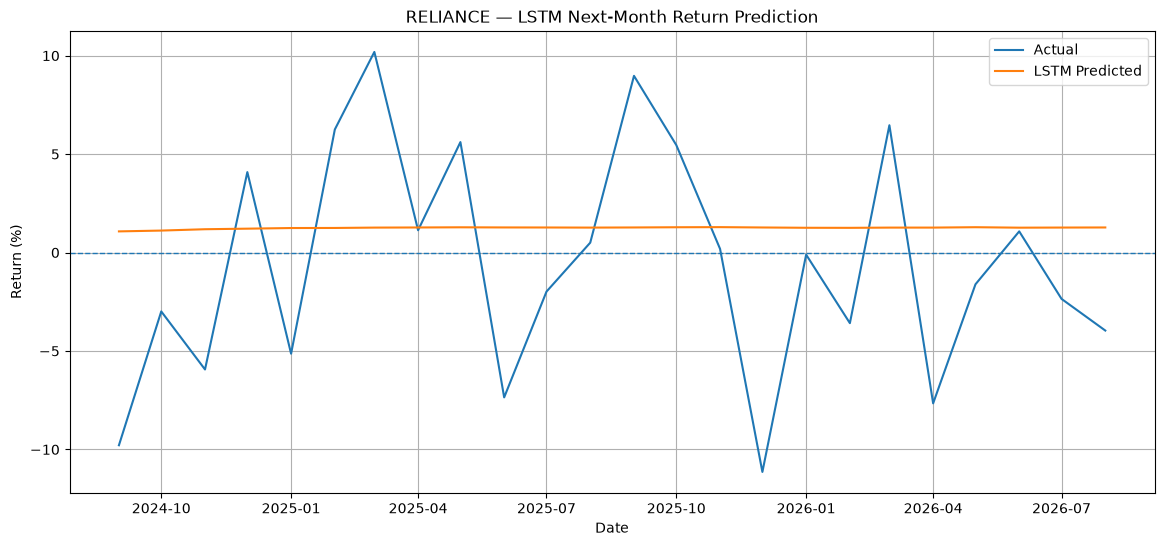

In [19]:
# ============================================================
# ACTUAL VS PREDICTED RETURNS
# ============================================================

test_dates = test["date"].values

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test_seq,
    label="Actual"
)

plt.plot(
    test_dates,
    y_pred,
    label="LSTM Predicted"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("RELIANCE — LSTM Next-Month Return Prediction")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)

plt.show()

Cell 14 — Direction accuracy

In [21]:
# ============================================================
# DIRECTIONAL ACCURACY
# ============================================================

actual_direction = np.sign(y_test_seq)
predicted_direction = np.sign(y_pred)

directional_accuracy = np.mean(
    actual_direction == predicted_direction
)

print(
    f"Directional Accuracy: "
    f"{directional_accuracy * 100:.2f}%"
)

Directional Accuracy: 45.83%


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# BASELINES ON THE SAME TEST SET
# ============================================================

# Baseline 1: Always predict 0%
zero_pred = np.zeros_like(y_test_seq)

zero_mae = mean_absolute_error(y_test_seq, zero_pred)
zero_rmse = np.sqrt(
    mean_squared_error(y_test_seq, zero_pred)
)


# Baseline 2: Always predict training mean
mean_return = y_train_seq.mean()

mean_pred = np.full_like(
    y_test_seq,
    mean_return,
    dtype=float
)

mean_mae = mean_absolute_error(y_test_seq, mean_pred)
mean_rmse = np.sqrt(
    mean_squared_error(y_test_seq, mean_pred)
)


# ============================================================
# COMPARE
# ============================================================

print("=" * 70)
print("BASELINE VS LSTM")
print("=" * 70)

print(f"\nZero-return baseline:")
print(f"MAE:  {zero_mae:.4f}")
print(f"RMSE: {zero_rmse:.4f}")

print(f"\nTraining-mean baseline:")
print(f"Mean return: {mean_return:.4f}%")
print(f"MAE:  {mean_mae:.4f}")
print(f"RMSE: {mean_rmse:.4f}")

print(f"\nLSTM:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

BASELINE VS LSTM

Zero-return baseline:
MAE:  4.7311
RMSE: 5.7369

Training-mean baseline:
Mean return: 1.7346%
MAE:  5.2128
RMSE: 6.1565

LSTM:
MAE:  5.0026
RMSE: 5.9746


In [23]:
# ============================================================
# LSTM V2 — FEATURE ENGINEERING
# ============================================================

lstm_data = reliance[
    [
        "date",
        "monthly_adj_close",
        "monthly_volume",
        "stock_return_1m",
        "oil_return_1m_pct",
        "gold_return_1m_pct",
        "target_return_1m"
    ]
].copy()

# ------------------------------------------------------------
# Stock momentum
# ------------------------------------------------------------

lstm_data["stock_return_3m"] = (
    lstm_data["monthly_adj_close"]
    .pct_change(3) * 100
)

lstm_data["stock_return_6m"] = (
    lstm_data["monthly_adj_close"]
    .pct_change(6) * 100
)


# ------------------------------------------------------------
# Stock volatility
# ------------------------------------------------------------

lstm_data["stock_volatility_3m"] = (
    lstm_data["stock_return_1m"]
    .rolling(3)
    .std()
)


# ------------------------------------------------------------
# Volume momentum
# ------------------------------------------------------------

lstm_data["volume_change_1m"] = (
    lstm_data["monthly_volume"]
    .pct_change() * 100
)


# ------------------------------------------------------------
# Select final features
# ------------------------------------------------------------

features_v2 = [
    "stock_return_1m",
    "stock_return_3m",
    "stock_return_6m",
    "stock_volatility_3m",
    "volume_change_1m",
    "oil_return_1m_pct",
    "gold_return_1m_pct"
]

target = "target_return_1m"

lstm_data = lstm_data[
    ["date"] + features_v2 + [target]
].copy()

print("=" * 70)
print("LSTM V2 FEATURES")
print("=" * 70)

print("\nFeatures:")
for feature in features_v2:
    print(" -", feature)

print("\nMissing values:")
print(lstm_data[features_v2 + [target]].isna().sum())

LSTM V2 FEATURES

Features:
 - stock_return_1m
 - stock_return_3m
 - stock_return_6m
 - stock_volatility_3m
 - volume_change_1m
 - oil_return_1m_pct
 - gold_return_1m_pct

Missing values:
stock_return_1m        0
stock_return_3m        3
stock_return_6m        6
stock_volatility_3m    2
volume_change_1m       1
oil_return_1m_pct      1
gold_return_1m_pct     1
target_return_1m       1
dtype: int64


In [24]:
lstm_data = (
    lstm_data
    .dropna()
    .reset_index(drop=True)
)

print("=" * 70)
print("LSTM V2 DATA")
print("=" * 70)

print("Shape:", lstm_data.shape)
print("Date range:",
      lstm_data["date"].min(),
      "→",
      lstm_data["date"].max())

display(lstm_data.head())

LSTM V2 DATA
Shape: (194, 9)
Date range: 2010-07-01 00:00:00 → 2026-08-01 00:00:00


,date,stock_return_1m,stock_return_3m,stock_return_6m,stock_volatility_3m,volume_change_1m,oil_return_1m_pct,gold_return_1m_pct,target_return_1m
0,2010-07-01,-7.358813,-1.594564,-2.779717,6.132433,-15.982241,4.226101,-5.204238,-8.958548
1,2010-08-01,-8.958548,-12.088751,-5.408889,7.198353,36.896538,2.641339,3.342215,7.403199
2,2010-09-01,7.403199,-9.414121,-7.418832,9.020189,3.206865,2.573367,3.234123,11.040734
3,2010-10-01,11.040734,8.577219,6.845886,10.652932,-0.121087,1.020537,3.142746,-10.093487
4,2010-11-01,-10.093487,7.223677,-5.738327,11.299122,-7.322259,3.331325,5.226437,7.416784


In [25]:
# ============================================================
# LSTM V2 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

test_size = 24

# Keep the final 24 months untouched for testing
train_val_v2 = lstm_data.iloc[:-test_size].copy()
test_v2 = lstm_data.iloc[-test_size:].copy()

# Use 20% of the remaining data for validation
val_size_v2 = int(len(train_val_v2) * 0.20)

train_v2 = train_val_v2.iloc[:-val_size_v2].copy()
validation_v2 = train_val_v2.iloc[-val_size_v2:].copy()

print("=" * 70)
print("LSTM V2 DATA SPLIT")
print("=" * 70)

print("\nTraining:")
print("Observations:", len(train_v2))
print("Period:", train_v2["date"].min(), "→", train_v2["date"].max())

print("\nValidation:")
print("Observations:", len(validation_v2))
print("Period:", validation_v2["date"].min(), "→", validation_v2["date"].max())

print("\nTesting:")
print("Observations:", len(test_v2))
print("Period:", test_v2["date"].min(), "→", test_v2["date"].max())

LSTM V2 DATA SPLIT

Training:
Observations: 136
Period: 2010-07-01 00:00:00 → 2021-10-01 00:00:00

Validation:
Observations: 34
Period: 2021-11-01 00:00:00 → 2024-08-01 00:00:00

Testing:
Observations: 24
Period: 2024-09-01 00:00:00 → 2026-08-01 00:00:00


In [26]:
# ============================================================
# LSTM V2 — FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler_v2 = StandardScaler()

scaler_v2.fit(train_v2[features_v2])

X_train_v2_scaled = scaler_v2.transform(
    train_v2[features_v2]
)

X_val_v2_scaled = scaler_v2.transform(
    validation_v2[features_v2]
)

X_test_v2_scaled = scaler_v2.transform(
    test_v2[features_v2]
)

print("Scaled shapes:")
print("X_train:", X_train_v2_scaled.shape)
print("X_val:  ", X_val_v2_scaled.shape)
print("X_test: ", X_test_v2_scaled.shape)

Scaled shapes:
X_train: (136, 7)
X_val:   (34, 7)
X_test:  (24, 7)


In [27]:
# ============================================================
# LSTM V2 — CREATE SEQUENCES
# ============================================================

LOOKBACK = 12

y_train_v2 = train_v2[target].values
y_val_v2 = validation_v2[target].values
y_test_v2 = test_v2[target].values


# ------------------------------------------------------------
# Training sequences
# ------------------------------------------------------------

X_train_v2_seq, y_train_v2_seq = create_sequences(
    X_train_v2_scaled,
    y_train_v2,
    LOOKBACK
)


# ------------------------------------------------------------
# Validation sequences
# Use final 12 training observations as context
# ------------------------------------------------------------

X_val_v2_context = X_train_v2_scaled[-LOOKBACK:]

X_val_v2_seq, y_val_v2_seq = create_sequences_with_context(
    X_val_v2_context,
    X_val_v2_scaled,
    y_val_v2,
    LOOKBACK
)


# ------------------------------------------------------------
# Test sequences
# Use final 12 validation observations as context
# ------------------------------------------------------------

X_test_v2_context = X_val_v2_scaled[-LOOKBACK:]

X_test_v2_seq, y_test_v2_seq = create_sequences_with_context(
    X_test_v2_context,
    X_test_v2_scaled,
    y_test_v2,
    LOOKBACK
)


# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

print("=" * 70)
print("LSTM V2 SEQUENCE SHAPES")
print("=" * 70)

print("X_train:", X_train_v2_seq.shape)
print("y_train:", y_train_v2_seq.shape)

print("X_val:  ", X_val_v2_seq.shape)
print("y_val:  ", y_val_v2_seq.shape)

print("X_test: ", X_test_v2_seq.shape)
print("y_test: ", y_test_v2_seq.shape)

LSTM V2 SEQUENCE SHAPES
X_train: (124, 12, 7)
y_train: (124,)
X_val:   (34, 12, 7)
y_val:   (34,)
X_test:  (24, 12, 7)
y_test:  (24,)


In [28]:
# ============================================================
# LSTM V2 MODEL
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model_v2 = Sequential([
    LSTM(
        64,
        input_shape=(LOOKBACK, len(features_v2))
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model_v2.summary()

c:\Users\313635\Downloads\Mutual Fund Disclosure Intelligence\backend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ============================================================
# TRAIN LSTM V2
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    X_train_v2_seq,
    y_train_v2_seq,

    validation_data=(
        X_val_v2_seq,
        y_val_v2_seq
    ),

    epochs=100,
    batch_size=16,

    callbacks=[early_stopping_v2],

    verbose=1
)

print("\nTraining completed.")
print("Epochs trained:", len(history_v2.history["loss"]))

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 71.1352 - mae: 6.4231 - val_loss: 29.8894 - val_mae: 4.4370
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 70.3194 - mae: 6.3911 - val_loss: 29.6119 - val_mae: 4.4164
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 69.8518 - mae: 6.3658 - val_loss: 29.4074 - val_mae: 4.4020
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69.1606 - mae: 6.3281 - val_loss: 29.2563 - val_mae: 4.3950
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 68.8756 - mae: 6.3273 - val_loss: 29.0846 - val_mae: 4.3852
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 68.2889 - mae: 6.3113 - val_loss: 28.9595 - val_mae: 4.3798
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 67.0313 - mae: 6.2895 - val_loss: 28.8701 - val_mae: 4.3943
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 66.2516 - mae: 6.2979 - val_loss: 29.1870 - val_mae: 4.4324
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - los

In [30]:
# ============================================================
# LSTM V2 TEST PREDICTION
# ============================================================

y_pred_v2 = model_v2.predict(
    X_test_v2_seq,
    verbose=0
).flatten()

mae_v2 = mean_absolute_error(
    y_test_v2_seq,
    y_pred_v2
)

rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test_v2_seq,
        y_pred_v2
    )
)

direction_v2 = np.mean(
    np.sign(y_test_v2_seq) == np.sign(y_pred_v2)
)

print("=" * 70)
print("LSTM V2 TEST RESULTS")
print("=" * 70)

print(f"MAE:  {mae_v2:.4f}")
print(f"RMSE: {rmse_v2:.4f}")
print(f"Directional Accuracy: {direction_v2 * 100:.2f}%")

LSTM V2 TEST RESULTS
MAE:  4.8379
RMSE: 5.8887
Directional Accuracy: 45.83%


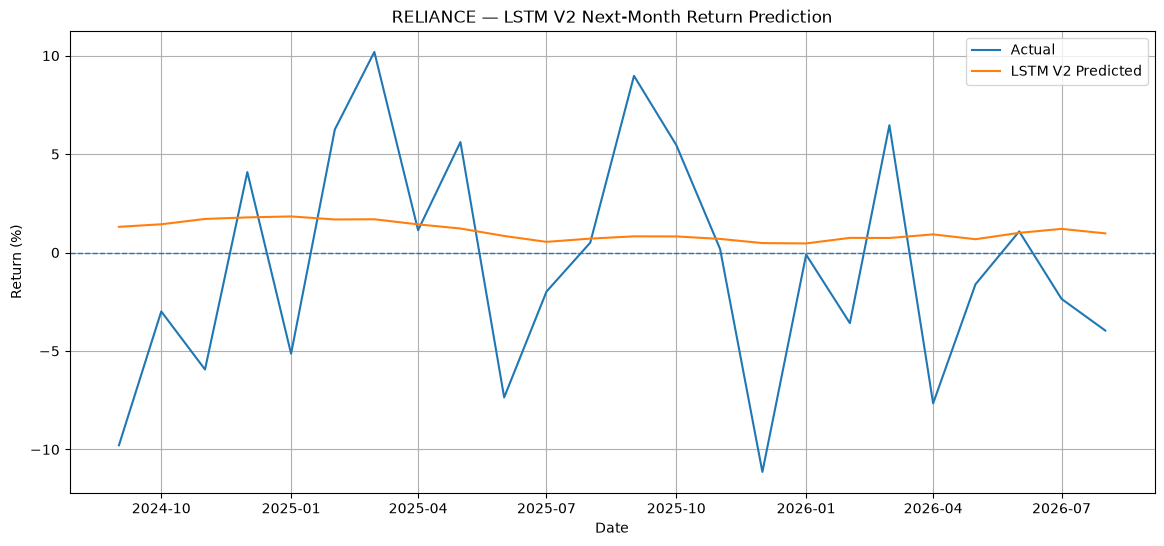

In [31]:
# ============================================================
# LSTM V2 — ACTUAL VS PREDICTED
# ============================================================

test_dates_v2 = test_v2["date"].values

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates_v2,
    y_test_v2_seq,
    label="Actual"
)

plt.plot(
    test_dates_v2,
    y_pred_v2,
    label="LSTM V2 Predicted"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("RELIANCE — LSTM V2 Next-Month Return Prediction")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
print("Actual:")
print(
    f"Min: {y_test_v2_seq.min():.2f}% | "
    f"Max: {y_test_v2_seq.max():.2f}% | "
    f"Mean: {y_test_v2_seq.mean():.2f}%"
)

print("\nPredicted:")
print(
    f"Min: {y_pred_v2.min():.2f}% | "
    f"Max: {y_pred_v2.max():.2f}% | "
    f"Mean: {y_pred_v2.mean():.2f}%"
)

Actual:
Min: -11.14% | Max: 10.19% | Mean: -0.57%

Predicted:
Min: 0.46% | Max: 1.83% | Mean: 1.07%
